# 1 · Sentiment Analysis — Text Preprocessing

1. Load `datasets/sentiment/sentiment.csv`
2. Clean text (lowercase, remove HTML/URLs, non-alpha chars)
3. Encode string labels → integer classes
4. Stratified train / test split
5. Fit Keras Tokeniser on training data
6. Pad sequences to fixed length
7. Save tokeniser → `models/sentiment/`
8. Save padded arrays → `artifacts/sentiment/`

**Expected CSV columns:** `text`, `label`  
**Expected label values:** `positive`, `negative`, `neutral`

## 0 · Imports & Config

In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import (
    SENTIMENT_DATASET_PATH,
    SENTIMENT_TOKENIZER_PATH,
    SENTIMENT_LABEL_ENC_PATH,
    SENTIMENT_TRAIN_ARTIFACT,
    SENTIMENT_TEST_ARTIFACT,
    SENTIMENT_ARTIFACT_DIR,
    SENTIMENT_MODEL_DIR,
    SENT_VOCAB_SIZE,
    SENT_MAX_LEN,
)
from src.common import set_seed, ensure_dirs
from src.sentiment.preprocessing import (
    load_sentiment_data,
    prepare_sentiment_dataset,
)

set_seed(42)
ensure_dirs(SENTIMENT_ARTIFACT_DIR, SENTIMENT_MODEL_DIR)

# ── USER SETTINGS ─────────────────────────────────────────────────────────────
TEXT_COL   = 'review'      # column name in your CSV
LABEL_COL  = 'sentiment'     # column name in your CSV
TEST_SIZE  = 0.2         # fraction held out for evaluation
# ─────────────────────────────────────────────────────────────────────────────

print('Config loaded.')

Config loaded.


## 1 · Load & Explore Dataset

In [2]:
df = load_sentiment_data(SENTIMENT_DATASET_PATH, TEXT_COL, LABEL_COL)

print(f'\nDataset shape : {df.shape}')
print(f'Null values   : {df.isnull().sum().to_dict()}')
df.head()

[INFO] Loaded 50,000 sentiment samples.
[INFO] Label distribution:
label
positive    25000
negative    25000

Dataset shape : (50000, 2)
Null values   : {'text': 0, 'label': 0}


,text,label
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there s a family where a little boy ...,negative
4,petter mattei s love in the time of money is a...,positive


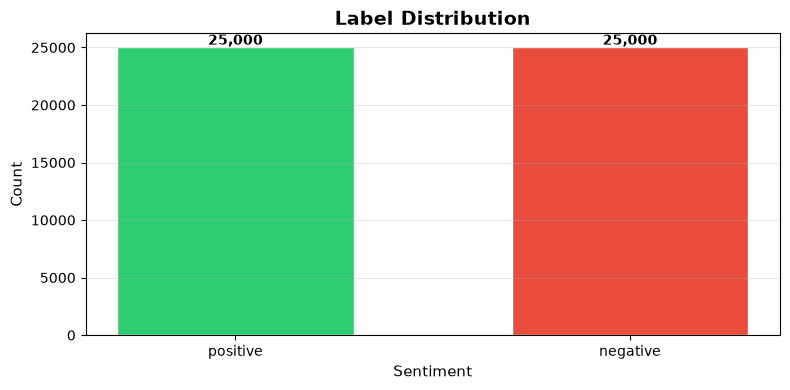

In [3]:
# Label distribution bar chart
label_counts = df['label'].value_counts()

colors = {'positive': '#2ECC71', 'negative': '#E74C3C', 'neutral': '#F39C12'}
bar_colors = [colors.get(l, '#3498DB') for l in label_counts.index]

plt.figure(figsize=(8, 4))
plt.bar(label_counts.index, label_counts.values, color=bar_colors, edgecolor='white', width=0.6)
plt.title('Label Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=11); plt.ylabel('Count', fontsize=11)
for i, (label, count) in enumerate(label_counts.items()):
    plt.text(i, count + label_counts.max() * 0.01, f'{count:,}',
             ha='center', fontsize=10, fontweight='bold')
plt.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig('label_distribution.png', dpi=120)
plt.show()

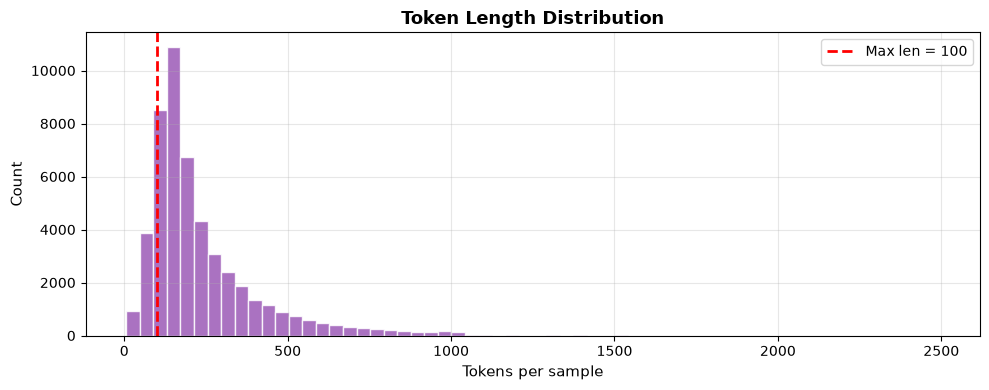

Samples within max_len (100): 12.2%


In [4]:
# Token length distribution
df['token_len'] = df['text'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 4))
plt.hist(df['token_len'], bins=60, color='#9B59B6', alpha=0.85, edgecolor='white')
plt.axvline(SENT_MAX_LEN, color='red', linestyle='--', linewidth=2,
            label=f'Max len = {SENT_MAX_LEN}')
plt.title('Token Length Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Tokens per sample', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

coverage = (df['token_len'] <= SENT_MAX_LEN).mean() * 100
print(f'Samples within max_len ({SENT_MAX_LEN}): {coverage:.1f}%')

## 2 · Full Preprocessing Pipeline

In [6]:
result = prepare_sentiment_dataset(
    csv_path            = SENTIMENT_DATASET_PATH,
    vocab_size          = SENT_VOCAB_SIZE,
    maxlen              = SENT_MAX_LEN,
    test_size           = TEST_SIZE,
    tokenizer_save_path = SENTIMENT_TOKENIZER_PATH,
    label_enc_save_path = SENTIMENT_LABEL_ENC_PATH,
)

X_train = result['X_train']
X_test  = result['X_test']
y_train = result['y_train']
y_test  = result['y_test']
tok     = result['tokenizer']
le      = result['label_encoder']

print('\n--- Shapes ---')
print(f'  X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'  X_test : {X_test.shape}   y_test : {y_test.shape}')
print(f'  Classes: {list(le.classes_)}')

[INFO] Loaded 50,000 sentiment samples.
[INFO] Label distribution:
label
positive    25000
negative    25000
[INFO] Label classes (alphabetical): [np.str_('negative'), np.str_('positive')]
[INFO] Split → Train: 40,000  |  Test: 10,000
[INFO] Sentiment tokenizer fitted — vocab: 90,384 (capped at 20,000)
[INFO] Sentiment tokenizer saved  →  c:\Users\himan\Documents\trial 2\models\sentiment\tokenizer.pkl
[INFO] LabelEncoder saved  →  c:\Users\himan\Documents\trial 2\models\sentiment\label_encoder.pkl

--- Shapes ---
  X_train: (40000, 100)  y_train: (40000,)
  X_test : (10000, 100)   y_test : (10000,)
  Classes: [np.str_('negative'), np.str_('positive')]


## 3 · Save Artifacts

In [7]:
with open(SENTIMENT_TRAIN_ARTIFACT, 'wb') as fh:
    pickle.dump({'X': X_train, 'y': y_train}, fh, protocol=pickle.HIGHEST_PROTOCOL)

with open(SENTIMENT_TEST_ARTIFACT, 'wb') as fh:
    pickle.dump({'X': X_test,  'y': y_test},  fh, protocol=pickle.HIGHEST_PROTOCOL)

print(f'Train artifact saved → {SENTIMENT_TRAIN_ARTIFACT}')
print(f'Test  artifact saved → {SENTIMENT_TEST_ARTIFACT}')

Train artifact saved → c:\Users\himan\Documents\trial 2\artifacts\sentiment\processed_train.pkl
Test  artifact saved → c:\Users\himan\Documents\trial 2\artifacts\sentiment\processed_test.pkl


## 4 · Vocabulary Statistics

In [8]:
print(f'Total unique tokens in corpus : {len(tok.word_index):,}')
print(f'Vocabulary cap                 : {SENT_VOCAB_SIZE:,}')
print('\nTop 20 most frequent words:')
top20 = sorted(tok.word_counts.items(), key=lambda x: -x[1])[:20]
for word, count in top20:
    print(f'  {word:<20} {count:,}')

Total unique tokens in corpus : 90,384
Vocabulary cap                 : 20,000

Top 20 most frequent words:
  the                  535,132
  and                  259,773
  a                    258,770
  of                   231,741
  to                   214,911
  is                   168,725
  it                   152,844
  in                   149,626
  i                    141,363
  this                 121,228
  that                 115,262
  s                    103,834
  was                  76,830
  as                   73,506
  movie                70,399
  for                  70,342
  with                 70,012
  but                  66,612
  film                 64,059
  you                  55,413


## Preprocessing Complete

Files saved:
- `models/sentiment/tokenizer.pkl`
- `models/sentiment/label_encoder.pkl`
- `artifacts/sentiment/processed_train.pkl`
- `artifacts/sentiment/processed_test.pkl`